# Tratamento da Unidade Movel Maracana

Este notebook organiza o tratamento horário da Unidade Móvel `Maracana` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da Unidade Móvel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade Móvel para evitar problemas de codificação e isolamos apenas os registros da Unidade Móvel `Maracana`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_m_maracana = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL MARACANA"].copy()

df_m_maracana["data"] = pd.to_datetime(df_m_maracana["data"])
df_m_maracana = df_m_maracana.sort_values("data").reset_index(drop=True)
df_m_maracana = df_m_maracana.drop_duplicates(subset="data", keep="first")
df_m_maracana = df_m_maracana.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade Movel Maracana:", df_m_maracana.shape)
display(df_m_maracana.head())

Dimensoes da base da Unidade Movel Maracana: (2101, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,UNIDADE MOVEL MARACANA,0.0,24.31,95.04,1.54,24.92,0.20,12.04,36.94,16.50,NaN,29.0,-22.910299,-43.235205
2012-01-01 01:30:00,UNIDADE MOVEL MARACANA,0.0,24.14,94.84,1.65,22.50,0.17,6.49,28.96,16.67,NaN,38.0,-22.910299,-43.235205
2012-01-01 02:30:00,UNIDADE MOVEL MARACANA,0.0,24.12,94.22,1.27,22.95,0.20,10.10,32.94,13.08,NaN,28.0,-22.910299,-43.235205
2012-01-01 03:30:00,UNIDADE MOVEL MARACANA,0.0,24.18,92.88,1.03,24.17,0.17,10.58,34.55,10.90,NaN,17.0,-22.910299,-43.235205
2012-01-01 04:30:00,UNIDADE MOVEL MARACANA,0.0,24.34,91.21,1.80,23.53,0.20,19.12,42.66,9.37,NaN,15.0,-22.910299,-43.235205


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_m_maracana, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
pm10,2101,100.00,0
o3,187,8.90,1914
pm2_5,123,5.85,1978
no,111,5.28,1990
no2,111,5.28,1990
nox,111,5.28,1990
so2,101,4.81,2000
temp,99,4.71,2002
ur,99,4.71,2002
co,99,4.71,2002


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_m_maracana_tratado = df_m_maracana.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_m_maracana[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_m_maracana_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_m_maracana_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
7,o3,interpolate_time,187,119,68
0,no,interpolate_time,111,72,39
1,no2,interpolate_time,111,72,39
4,nox,interpolate_time,111,72,39
3,pm2_5,interpolate_time,123,91,32
2,so2,interpolate_time,101,72,29
5,ur,interpolate_time,99,71,28
6,temp,interpolate_time,99,71,28
8,co,interpolate_time,99,72,27
9,pm10,interpolate_time,2101,2101,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 329


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
o3,187,8.90,119,5.66,68,36.36
no2,111,5.28,72,3.43,39,35.14
no,111,5.28,72,3.43,39,35.14
nox,111,5.28,72,3.43,39,35.14
pm2_5,123,5.85,91,4.33,32,26.02
so2,101,4.81,72,3.43,29,28.71
temp,99,4.71,71,3.38,28,28.28
ur,99,4.71,71,3.38,28,28.28
co,99,4.71,72,3.43,27,27.27
pm10,2101,100.00,2101,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
no,33.676513,24.650,28.786534,33.410419,24.46,28.624052,-0.266094,-0.162482
no2,27.615558,24.805,13.439559,27.651244,24.89,13.457846,0.035687,0.018288
so2,11.180610,7.690,10.363665,11.262839,7.82,10.425912,0.082229,0.062247
pm2_5,18.426188,16.000,12.021598,18.448010,16.00,12.063172,0.021822,0.041573
nox,61.246849,52.635,35.153944,61.012570,52.57,34.989244,-0.234279,-0.164700
ur,66.221154,66.895,15.712506,66.111828,66.81,15.681019,-0.109326,-0.031487
temp,28.156998,27.570,3.532191,28.176975,27.59,3.526173,0.019977,-0.006018
o3,24.276014,12.965,28.560066,24.360860,12.88,28.642839,0.084847,0.082774
co,0.217008,0.140,0.225065,0.216247,0.14,0.223938,-0.000761,-0.001127
chuva,0.125746,0.000,0.890076,0.125746,0.00,0.890076,0.000000,0.000000


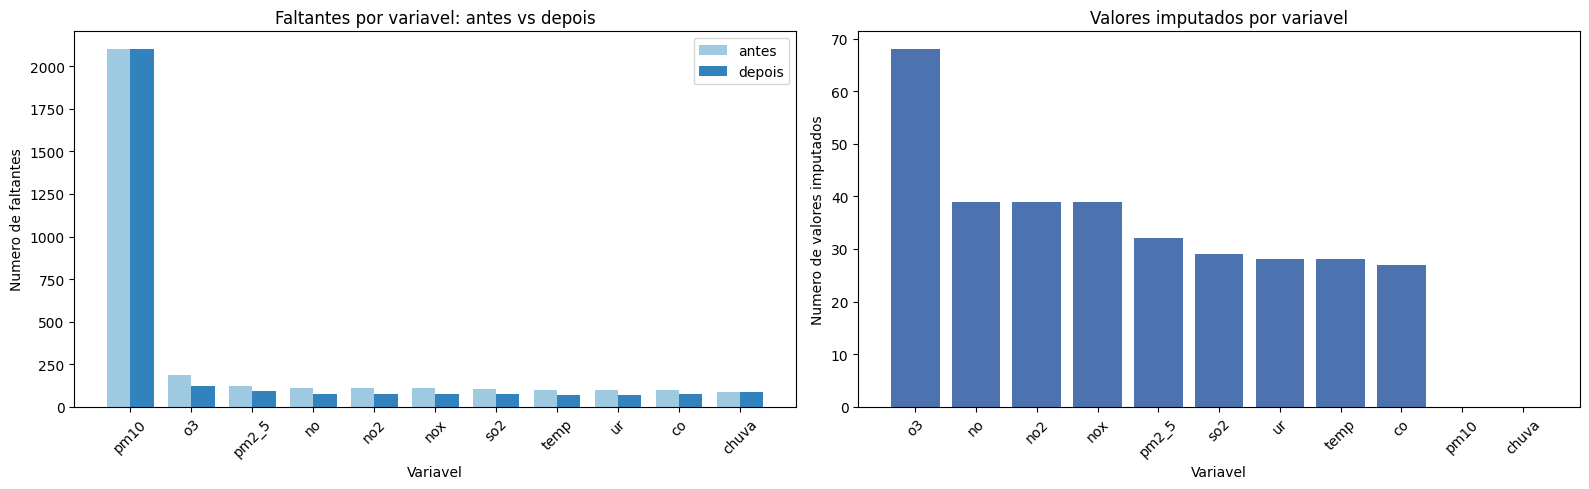

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_m_maracana_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_m_maracana[variavel].notna().any() or df_m_maracana_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_m_maracana, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_m_maracana_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a Unidade Movel `Maracana`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_um_maracana_diario = (
    df_m_maracana_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

df_um_maracana_diario_saida = df_um_maracana_diario.reset_index()
output_csv_diario_path = output_dir / "um_maracana_tratado_diario.csv"
df_um_maracana_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_um_maracana_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_maracana_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,13.102917,21.211667,2.722500,14.625000,34.183333,89.122917,25.412083,17.291667,0.258750,NaN,15.0
1,2012-01-02,58.560417,28.232083,2.864167,12.166667,86.797917,96.105000,22.067083,5.731250,0.442083,NaN,48.0
2,2012-01-03,38.897500,25.700833,4.413333,13.833333,64.357083,68.303333,24.920833,13.927083,0.138333,NaN,0.0
3,2012-01-04,43.554583,24.308750,3.808333,15.208333,67.882917,68.307083,25.503333,11.697917,0.218333,NaN,0.0
4,2012-01-05,25.168750,25.188750,2.467917,13.208333,50.223750,73.912500,25.873750,25.188750,0.116667,NaN,0.0


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Maracanã` manteve a estratégia conservadora de interpolação temporal em lacunas curtas (até `4` horas) e melhorou a completude sem alterar, de forma relevante, o comportamento geral das séries. No total, foram imputados `329` valores, com maior contribuição em `o3` (`68`), `no` (`39`), `no2` (`39`) e `nox` (`39`), além de ganhos em `pm2_5` (`32`), `so2` (`29`), `temp` (`28`), `ur` (`28`) e `co` (`27`).

As reduções de dados faltantes foram mais evidentes em `o3` (`8,90%` para `5,66%`), `no` (`5,28%` para `3,43%`), `no2` (`5,28%` para `3,43%`) e `nox` (`5,28%` para `3,43%`). Também houve melhora em `pm2_5` (`5,85%` para `4,33%`), `so2` (`4,81%` para `3,43%`), `temp` (`4,71%` para `3,38%`), `ur` (`4,71%` para `3,38%`) e `co` (`4,71%` para `3,43%`).

Em contrapartida, `pm10` permaneceu com `100%` de dados faltantes, indicando ausência estrutural desse poluente na campanha. `chuva` ficou sem imputação. A comparação estatística antes e depois mostra variações pequenas em `média`, `mediana` e `desvio_padrao`, sugerindo ganho de completude com baixo risco de distorção das distribuições originais.
